In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
import regex as re
import numpy as np
import fasttext

In [6]:
data = pd.read_csv('new_data.csv')

In [7]:
data.head()

,Label,Language
0,WZ,Tabara waksa tactar bal taraf ya ta bai ghara ...
1,WZ,Sa ta waya Cha sabaqai agha ta mo prazdi na ka...
2,WZ,Pelican arwan dii rawdra ragar ma naki dlta Sh...
3,WZ,Sabo var shey aghar Sara gupshap walaga v JAMA...
4,WZ,Za harcha ws by mo Tara os nasta lashki mosara...


In [8]:
data.dropna(inplace=True)

<Axes: ylabel='count'>

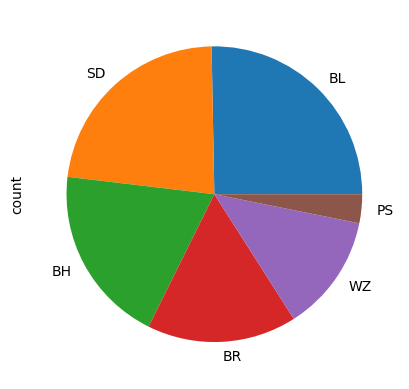

In [9]:
data['Label'].value_counts().plot.pie()

In [10]:
data['Label']=data['Label']
data['Label']='__label__'+data['Label'].astype(str)
data.head()

,Label,Language
0,__label__WZ,Tabara waksa tactar bal taraf ya ta bai ghara ...
1,__label__WZ,Sa ta waya Cha sabaqai agha ta mo prazdi na ka...
2,__label__WZ,Pelican arwan dii rawdra ragar ma naki dlta Sh...
3,__label__WZ,Sabo var shey aghar Sara gupshap walaga v JAMA...
4,__label__WZ,Za harcha ws by mo Tara os nasta lashki mosara...


In [11]:
def preprocessing(text):
  text=re.sub(r'[^\w\s]', ' ', text)
  text=re.sub(r' +', ' ', text)
  return text.strip().lower()

In [12]:
data['Language']=data['Language'].map(preprocessing)

In [13]:
data

,Label,Language
0,__label__WZ,tabara waksa tactar bal taraf ya ta bai ghara ...
1,__label__WZ,sa ta waya cha sabaqai agha ta mo prazdi na ka...
2,__label__WZ,pelican arwan dii rawdra ragar ma naki dlta sh...
3,__label__WZ,sabo var shey aghar sara gupshap walaga v jama...
4,__label__WZ,za harcha ws by mo tara os nasta lashki mosara...
...,...,...
451097,__label__BH,بالکل ویسے حالات ابھی پاکستان میں پختونوں کا ج...
451098,__label__BH,ہاں یہ پختونوں کے ساتھ بھی چل رہا ہے جب ہم دوس...
451099,__label__BH,شہید ہو رہے ہیں دوستو پتہ نہ ایک ہی سوال ہے پر...
451100,__label__BH,اپنے مستقبل کے لیے اپنے بھائی بہنوں ماں باپ کے...


In [14]:
x_train, x_test, y_train ,y_test= train_test_split(data['Language'],data['Label'],test_size=0.2,random_state=42)

In [15]:
x_train

127981    imtahana ni roasha ni andara kahmoshi yak soi ...
284611            اسان کي هڪ ٻئي سان آرام سان ڳالهائڻ گهرجي
98270     anda kaas masak lakin ara tim a kara matav ak ...
401320        جہاگرا نی بیس رشتہ در یکّ و دومیگا الزام دِیا
134091    guda ameshe a ha shotha hap rnda guda mn chare...
                                ...                        
259231                        مون کي پنهنجو تعارف ڪرائڻ ڏيو
366347    آرچیزے زَندارا مُول ءُ مُراد اِنت چِہ ھَے اِنس...
131985    dese dal aur sabzi hamesha za garebe amere dow...
146920    lekin laalach key astinaa n mardumey hamey kul...
122011    garm inga ilaqa na mosam ana hisab ana darakht...
Name: Language, Length: 359688, dtype: object

In [16]:
x_train.shape

(359688,)

In [17]:
y_train

127981    __label__BL
284611    __label__SD
98270     __label__BR
401320    __label__BL
134091    __label__BL
             ...     
259231    __label__SD
366347    __label__BL
131985    __label__BL
146920    __label__BL
122011    __label__BR
Name: Label, Length: 359688, dtype: object

In [18]:
y_train.shape

(359688,)

In [19]:
from imblearn.over_sampling import RandomOverSampler

ros= RandomOverSampler(sampling_strategy='auto')
x_res, y_res= ros.fit_resample(x_train.to_frame(),y_train)

In [20]:
x_res=x_res.squeeze()
train= y_res+" "+x_res

In [21]:
x_res.shape

(546156,)

In [27]:
check = pd.concat([x_res, y_res], axis=1)

<Axes: ylabel='count'>

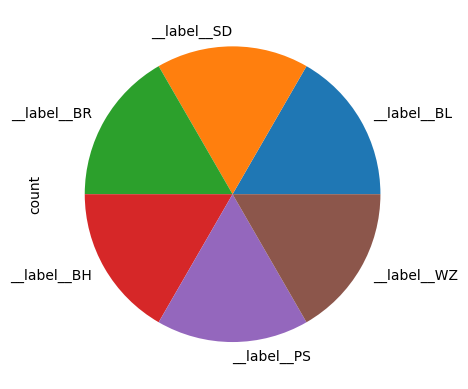

In [33]:
check["Label"].value_counts().plot.pie()

In [19]:
test=y_test+" "+x_test

In [134]:
train

0         __label__BL imtahana ni roasha ni andara kahmo...
1         __label__SD اسان کي هڪ ٻئي سان آرام سان ڳالهائ...
2         __label__BR anda kaas masak lakin ara tim a ka...
3         __label__BL جہاگرا نی بیس رشتہ در یکّ و دومیگا...
4         __label__BL guda ameshe a ha shotha hap rnda g...
                                ...                        
546151    __label__WZ da malk der kharop dai khas kar da...
546152    __label__WZ سئی ہوٹل موٹل تم بوزہ سئی روٹئی در...
546153    __label__WZ insan pa zndagi dase tera shi kna ...
546154    __label__WZ میژ دا دی پَہ چار شی چار نہ ساتی م...
546155    __label__WZ زا دلته راغلے یم سکول ته ایاز خوا ...
Length: 546156, dtype: object

In [135]:
test

295058    __label__SD منهنجو پيء ايندڙ هفتي پرڏيهه وڃڻ و...
127110    __label__BL bandar gah taraqi wajhash keh aste...
344326    __label__BR مرضی نا نی تینا مرضی نا مالک اُس ا...
419336    __label__BH دوسری یہ کہ مثال اپ نے ابھی لوگوں ...
296894      __label__SD اندر اچڻ کان اڳ توکي دٻائڻ گهرجي ها
                                ...                        
246243    __label__WZ دا لز پَ ضرورت ہَ دی زَ خپل ضرورت ...
416780    __label__BH اس کے بعد یہ ہے گنوں والے کے لیے چ...
29798         __label__SD kanhin tawhaan ji madad kaei taam
105794    __label__BR amo qabeela ak ara kay poora baloc...
437776    __label__BH اپنی کوشش سے اپنی جان نہ چھڑائیں ک...
Length: 89923, dtype: object

In [136]:
train.to_csv("language.train",index=False,header=False)
test.to_csv("language.test",index=False,header=False)

In [ ]:
model=fasttext.train_supervised(input="language.train",
    epoch=25,
    lr=1.0,
    wordNgrams=2,
    dim=100)

In [ ]:
result = model.test("language.test")
print("Precision:", result[1])
print("Recall:", result[2])

In [ ]:
user= input("Enter your text")
user_text= preprocessing(user)
model.predict(user_text)

In [ ]:
model.save_model("language_detector.bin")